In [ ]:
!pip install "datasets<4.0.0" transformers evaluate scikit-learn

In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "bgglue/bgglue",
    "fakenews",
    trust_remote_code=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['title', 'content', 'date_published', 'url', 'label'],
        num_rows: 1990
    })
    validation: Dataset({
        features: ['title', 'content', 'date_published', 'url', 'label'],
        num_rows: 221
    })
    test: Dataset({
        features: ['title', 'content', 'date_published', 'url', 'label'],
        num_rows: 701
    })
})


In [ ]:
print(dataset["train"].features)

{'title': Value(dtype='string', id=None), 'content': Value(dtype='string', id=None), 'date_published': Value(dtype='string', id=None), 'url': Value(dtype='string', id=None), 'label': ClassLabel(names=['credible', 'fake'], id=None)}


In [ ]:
print(dataset["train"][0])

{'title': 'Petel.bg - новини - "България днес": Изкопаха изгубеното пророчество на Слава Севрюкова за България! То се сбъдва пред очите ни', 'content': 'Изследователят на българските пророци Христо Радев\xa0разкрива предсказания на феномена Слава Севрюкова в интервю за „България днес“ „В края на 80-те години\xa0Слава Севрюкова\xa0казва, че в България изневиделица ще се появи човек, в който е прероден духът на ярък библейски герой. Има предвид Давид. Според ясновидката този българин ще изпълни много важна роля в бъдещето на страната. Дано този президент да е въпросният човек! Румен Радев изскочи от нищото, също като библейския Давид… Но всеки се разкрива чрез делата си. Предстои да видим дали той е човекът от предсказанието“ – твърди Христо Нанев. На въпрос дали съвпадат предсказанията на Ванга и\xa0Слава Севрюкова, Христо Нанев отговаря: „Съвпадат в голяма степен. Правил съм изследвания и сравнения в тази посока. За изселническите вълни от мюсюлмани например Ванга има повече предсказан

In [ ]:
for split in dataset:
    print(split, len(dataset[split]))

train 1990
validation 221
test 701


In [ ]:
import pandas as pd

df = pd.DataFrame(dataset["train"])
df["label"].value_counts()

,count
label,
0,1329
1,661


In [ ]:
print(dataset["train"].features["label"])
print(dataset["train"].features["label"].names)

ClassLabel(names=['credible', 'fake'], id=None)
['credible', 'fake']


In [ ]:
df.isnull().sum()

,0
title,0
content,0
date_published,0
url,0
label,0


In [ ]:
df.duplicated(subset=["content"]).sum()

np.int64(0)

In [ ]:
df["text_length"] = df["content"].str.len()
df["text_length"].describe()

,text_length
count,1990.000000
mean,4892.841206
std,6112.730265
min,35.000000
25%,1309.000000
50%,2444.500000
75%,5942.250000
max,32023.000000


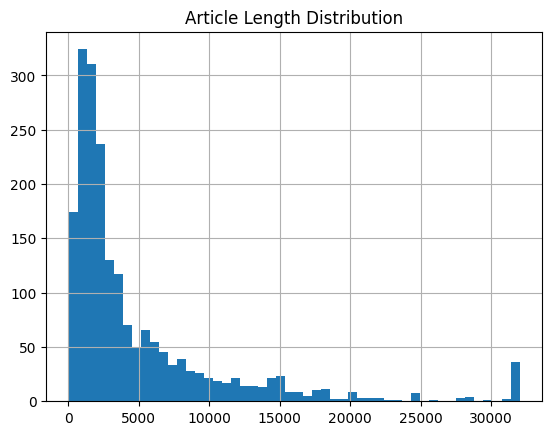

In [ ]:
import matplotlib.pyplot as plt

df["text_length"].hist(bins=50)
plt.title("Article Length Distribution")
plt.show()

In [ ]:
df["word_count"] = df["content"].str.split().apply(len)

df["word_count"].describe()

,word_count
count,1990.000000
mean,777.797487
std,956.234719
min,7.000000
25%,208.000000
50%,395.000000
75%,947.000000
max,6705.000000


In [ ]:
df.groupby("label")["word_count"].mean()

,word_count
label,
0,821.387509
1,690.155825


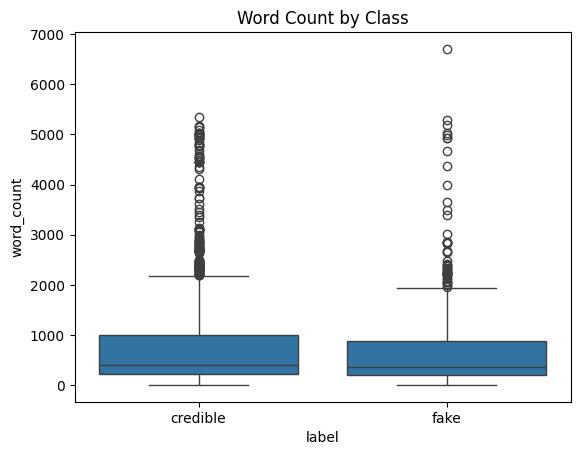

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="label", y="word_count")

plt.xticks([0,1], ["credible", "fake"])
plt.title("Word Count by Class")
plt.show()